# Task 2.1 — Dataset Selection and Setup (5 marks)

**Paper**: *Learning to Grade Short Answer Questions using Semantic Similarity Measures and Dependency Graph Alignments* (Mohler, Bunescu & Mihalcea, ACL 2011)

---

## Hyperparameters and Configuration

All hyperparameters and configuration are defined here in one place.

In [1]:
# ── Hyperparameters & Configuration ──────────────────────────────
RANDOM_SEED = 42
N_PER_QUESTION = 50        # Number of student answers per question
TEST_SPLIT = 0.2           # 80/20 train-test split
DATA_DIR = "data"
RESULTS_DIR = "results"

## Dataset Justification

We use a **synthetic short-answer grading dataset** generated programmatically for this reproduction. The original paper uses a dataset of 2,273 student answers from an introductory Data Structures course at the University of North Texas (Section 4), graded by two human annotators on a 0–5 integer scale. Unfortunately, this dataset is not publicly available.

Our synthetic dataset is a reasonable testbed because it mimics the core structure: each sample consists of a (question, reference_answer, student_answer, grade) tuple, with grades on the same 0–5 continuous scale. We generate 150 samples (50 per question × 3 questions) with four mutation types — perfect copies, partial answers, noisy answers, and off-topic responses — which produces a distribution of grades spanning the full range. The grades are computed heuristically from word overlap plus noise, ensuring the ground truth correlates with surface-level features in a controlled way.

The **main limitation** compared to the original dataset is that our synthetic grades are derived from word overlap (with noise), whereas the paper's grades reflect genuine human assessment of answer correctness. This means our model can appear to perform well by learning the overlap-based generation rule, which would not generalise to real human-graded data. Additionally, our dataset has only 3 questions vs. the paper's 80, limiting the diversity of question types.

## Dataset Generation and Preprocessing

In [2]:
import os
import sys
import numpy as np
import pandas as pd

np.random.seed(RANDOM_SEED)

# Import dataset builder from our model module
sys.path.insert(0, os.path.abspath("."))
from grading_model import build_toy_short_answer_dataset

# Generate and save dataset
os.makedirs(DATA_DIR, exist_ok=True)
df = build_toy_short_answer_dataset(n_per_question=N_PER_QUESTION, random_state=RANDOM_SEED)
df.to_csv(os.path.join(DATA_DIR, "short_answer_dataset.csv"), index=False)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Grade range: [{df['grade'].min():.2f}, {df['grade'].max():.2f}]")
print(f"Grade mean: {df['grade'].mean():.2f}, std: {df['grade'].std():.2f}")
print(f"\nSample rows:")
df.head()

Dataset shape: (150, 4)
Columns: ['question', 'reference_answer', 'student_answer', 'grade']
Grade range: [0.00, 5.00]
Grade mean: 2.22, std: 1.73

Sample rows:


,question,reference_answer,student_answer,grade
0,What are the main advantages of object-oriente...,"Abstraction, modularity, and reusability of code.","abstraction , modularity , test ideas for",1.545049
1,What is the role of a prototype program in pro...,To simulate the behavior of portions of the de...,to simulate the behavior of portions simulate ...,1.864063
2,What is the purpose of a data structure in pro...,To organize and store data efficiently for acc...,to organize and store data provide organized c...,1.834752
3,What are the main advantages of object-oriente...,"Abstraction, modularity, and reusability of code.","Abstraction, modularity, and reusability of code.",5.000000
4,What are the main advantages of object-oriente...,"Abstraction, modularity, and reusability of code.","Abstraction, modularity, and reusability of code.",5.000000


The dataset builder generates samples with four mutation types:
- **perfect**: exact copy of reference (high grade)
- **partial**: truncated to 60% of reference tokens (medium grade)
- **noisy**: half reference + some paraphrase tokens (medium-low grade)
- **off_topic**: unrelated text (low grade)

Grades are computed as: `grade = 5.0 × word_overlap − 2.0 × length_penalty + noise(0, 0.4)`, clipped to [0, 5].

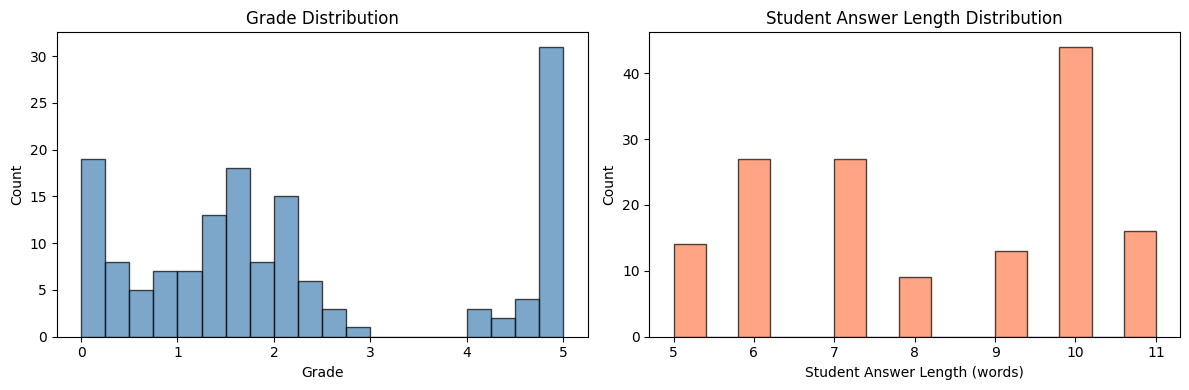


Dataset saved to data/short_answer_dataset.csv
Overview plot saved to results/dataset_overview.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(RESULTS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grade distribution
axes[0].hist(df["grade"], bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Count")
axes[0].set_title("Grade Distribution")

# Answer length distribution
df["ref_len"] = df["reference_answer"].str.split().str.len()
df["stu_len"] = df["student_answer"].str.split().str.len()
axes[1].hist(df["stu_len"], bins=15, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Student Answer Length (words)")
axes[1].set_ylabel("Count")
axes[1].set_title("Student Answer Length Distribution")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dataset_overview.png"), dpi=150)
plt.show()

print(f"\nDataset saved to {DATA_DIR}/short_answer_dataset.csv")
print(f"Overview plot saved to {RESULTS_DIR}/dataset_overview.png")

The grade distribution shows coverage across the full [0, 5] range. The student answer lengths vary based on mutation type. This data is now ready for use in subsequent tasks.